<a href="https://colab.research.google.com/github/Nhd-github/BootStrap_Page/blob/main/SimpleDomainAdaptation_hands_on.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Simple Domain Adaptation with MMD loss

Today, we are introducing the usage of **PyTorch** ([Documentation here](https://pytorch.org/docs/stable/index.html)), with **Torchvision** ([Documentation here](https://pytorch.org/vision/stable/)).  

In the next cell you can find the necessary imports for today's lab

In [1]:
import os
import torch
import torchvision
from torchvision import transforms, datasets
import torch.nn as nn
import time
import random
import numpy as np
from torchvision import models
from tqdm import tqdm

In [2]:
print("Is GPU+CUDA available and configured?", torch.cuda.is_available())

Is GPU+CUDA available and configured? True


### Run the next cell for downloading and extracting the OfficeHome Dataset ([homepage](https://www.hemanthdv.org/officeHomeDataset.html)).

In [3]:
!wget -nc https://wjdcloud.blob.core.windows.net/dataset/OfficeHome.zip
!unzip OfficeHome.zip

Streaming output truncated to the last 5000 lines.
  inflating: OfficeHome/Product/Speaker/00050.jpg  
  inflating: OfficeHome/Product/Speaker/00051.jpg  
  inflating: OfficeHome/Product/Speaker/00052.jpg  
  inflating: OfficeHome/Product/Speaker/00053.jpg  
  inflating: OfficeHome/Product/Speaker/00054.jpg  
  inflating: OfficeHome/Product/Speaker/00055.jpg  
  inflating: OfficeHome/Product/Speaker/00056.jpg  
  inflating: OfficeHome/Product/Speaker/00057.jpg  
  inflating: OfficeHome/Product/Speaker/00058.jpg  
  inflating: OfficeHome/Product/Speaker/00059.jpg  
  inflating: OfficeHome/Product/Speaker/00060.jpg  
  inflating: OfficeHome/Product/Speaker/00061.jpg  
  inflating: OfficeHome/Product/Speaker/00062.jpg  
  inflating: OfficeHome/Product/Speaker/00063.jpg  
  inflating: OfficeHome/Product/Speaker/00064.jpg  
  inflating: OfficeHome/Product/Speaker/00065.jpg  
  inflating: OfficeHome/Product/Speaker/00066.jpg  
  inflating: OfficeHome/Product/Speaker/00067.jpg  
  inflating: 

In [4]:
# You can already prepare a folder for storing your checkpoints
os.makedirs("./checkpoints", exist_ok=True)

#### Setting a seed for Reproducibility and Sanity Checks

The function `set_seed` allows you to fix the seed for all the operations that depend on pseudorandom generators. This can include random data splitting, operations inside neural networks, approximate solutions of internal solvers, etc.

Setting a seed is useful whenever you need to keep under control the randomness of your experiments. Setting a global seed should make your runs always consistent, at least when run on the same machine. If you want you can try to change it and collect multiple results.

In [5]:
def set_seed(seed: int = 0):
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


set_seed(110) # you can change your seed here


A very simple implementation for a custom Dataset in Pytorch. Whenever you may need slightly more control on how data is loaded from disk, you can implement a class (inheriting from `torch.utils.data.Dataset`) which has to provide at least a constructor and two methods:
+ `__len__(self)`: it allows the python function `len` to work on your dataset object.
+ `___getitem__(self, index)`: it implements the array-like access operator on your dataset object (e.g., `a = [1, 2, 3, 4, 5]; a[2] = 3`).

These methods will be used by the `torch.utils.data.DataLoader` objects, which will handle how minibatches are built when you actually feed data to your network.

In [6]:
from torch.utils.data import Dataset, random_split

class CustomDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x, y = self.dataset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

Utility function for preparing your datasets

NB: `transforms_dict` contains two transforms, one for training data, and one for evaluation data (either used for validation or test)

First, we load the dataset folder as an `ImageFolder` dataset ([docs](https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html)).

At this point we need to isolate at least a test set for measuring our model performance. (Labs have limited time slots, always remember that isolating a validation set for model selection is usually required to obtain a better model, and no actual hyperparameter tuning should be done either on train or test data.)

For source data, we are keeping 80% of data for training and 20% for testing.
For target data, we hare splitting the dataset in half.  
**NB**: `random_split` does not stratify!

The previously defined `CustomDataset` is now useful to assign a different data transform to data, depending on it being used for training or for evaluation. (You don't want random augmentations on evaluation data!)


In [8]:
import os
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

# فرض بر اینه که CustomDataset از قبل تعریف شده

def prepare_data(root_path, domain, batch_size, is_source=True):
    transform_dict = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],    # ImageNet mean
                std=[0.229, 0.224, 0.225]      # ImageNet std
            ),
        ]),
        'eval': transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],    # Same as above
                std=[0.229, 0.224, 0.225]
            ),
        ])
    }

    # Load dataset from domain folder
    dataset = datasets.ImageFolder(root=os.path.join(root_path, domain))
    total_len = len(dataset)

    # Split source 80/20, target 50/50
    if is_source:
        train_len = int(0.8 * total_len)
    else:
        train_len = total_len // 2
    eval_len = total_len - train_len

    train_subset, eval_subset = random_split(dataset, lengths=[train_len, eval_len])

    # Wrap in CustomDataset with proper transforms
    train_data = CustomDataset(train_subset, transform=transform_dict['train'])
    eval_data = CustomDataset(eval_subset, transform=transform_dict['eval'])

    return train_data, eval_data


Now, we can actually setup our datasets, dataloaders, computing device, etc.
Source domain is "RealWorld", while Target one is "Art".

In [10]:
from torch.utils.data import DataLoader
import torch

# مسیر دیتاست
DATA_FOLDER = "./OfficeHome"

# نام دامنه‌ها (مثال: Art → source، Clipart → target)
SRC_DOMAIN = "Art"
TGT_DOMAIN = "Clipart"

# سایز هر batch
BATCH_SIZE = 32

# تشخیص خودکار استفاده از GPU یا CPU
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# آماده‌سازی داده‌ها
src_tr_set, src_val_set = prepare_data(DATA_FOLDER, SRC_DOMAIN, BATCH_SIZE, is_source=True)
tar_tr_set, tar_te_set  = prepare_data(DATA_FOLDER, TGT_DOMAIN, BATCH_SIZE, is_source=False)

# ساختن DataLoader برای هر مجموعه داده
src_tr_loader  = DataLoader(src_tr_set, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  num_workers=2)
src_val_loader = DataLoader(src_val_set, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=2)
tar_tr_loader  = DataLoader(tar_tr_set, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  num_workers=2)
tar_te_loader  = DataLoader(tar_te_set, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=2)

# نمایش تعداد نمونه‌ها در هر بخش
print(f'Source training size: {len(src_tr_set)}')
print(f'Source held-out size: {len(src_val_set)}')
print(f'Target training size: {len(tar_tr_set)}')
print(f'Target test     size: {len(tar_te_set)}')


Source training size: 1941
Source held-out size: 486
Target training size: 2182
Target test     size: 2183


We can show some of the images.
In our case we need to deal with a few things first.

Look at all the required operations, then run the cell.

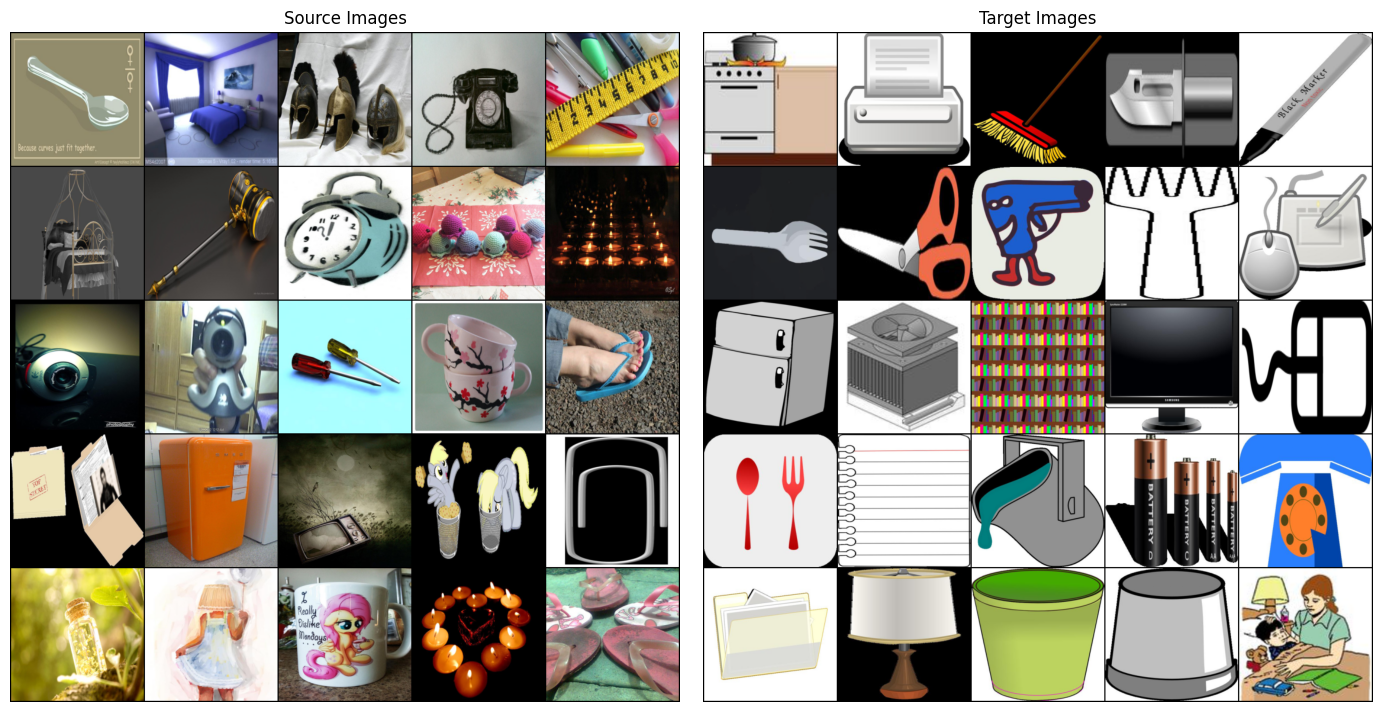

In [11]:
import torch
from torchvision.utils import make_grid  # utility for showing grids of images
from matplotlib import pyplot as plt

# Define ImageNet normalization stats
imagenet_mean = torch.tensor([0.485, 0.456, 0.406])
imagenet_std  = torch.tensor([0.229, 0.224, 0.225])

def denormalize(img_tensor):
    # Reverse normalization for ImageNet: (img * std) + mean.
    img_tensor = img_tensor.clone()  # Avoid modifying the original tensor
    img_tensor = img_tensor * imagenet_std[:, None, None] + imagenet_mean[:, None, None]
    return img_tensor

plt.figure(figsize=(14, 7))

# Pick every 10th image from first 250 in source and target validation/test sets
src_imgs = [denormalize(src_val_set[i][0]) for i in range(0, 250, 10)]
tar_imgs = [denormalize(tar_te_set[i][0]) for i in range(0, 250, 10)]

# Create image grids
src_grid = make_grid(torch.stack(src_imgs), nrow=5)
tar_grid = make_grid(torch.stack(tar_imgs), nrow=5)

# Plot source images
plt.subplot(1, 2, 1)
plt.imshow(src_grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Source Images")

# Plot target images
plt.subplot(1, 2, 2)
plt.imshow(tar_grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Target Images")

plt.tight_layout()
plt.show()


We can now define a simple class that customizes a backbone (that can be imagenet pretrained) to replace the original classification head (a linear layer with 1000 neurons) with a new one for our classification task (which has 65 target classes).

All pytorch models are objects that inherit from `nn.Module`. This is also the case for many layers, loss functions, etc.

In [12]:
class GenericDNN(nn.Module):
    def __init__(self, base_model_name: str = "resnet18", pretrained: bool = True, num_classes: int = 65):
        super().__init__()

        self.base_model_name  = base_model_name
        self.pretrained       = pretrained
        self.num_classes      = num_classes

        match self.base_model_name:
            case "resnet18":
                pretrained_weights = models.ResNet18_Weights.DEFAULT if self.pretrained else None # pretrained weights or not
                self.model = models.resnet18(weights=pretrained_weights) # model construction
                self.embedding_dim = self.model.fc.in_features # we can store the dimensionality of backbone's embedding

                # Our new classification head is a linear layer that takes
                # (Batch_Size, Emedding_Dim) in input and outputs logits (for 65 classes)
                self.fc = nn.Linear(self.embedding_dim, self.num_classes)

            # In case one wants to try a different backbone architecture
            # it is sufficient to define a different case for another architecture.
            # You can do "print(model)" to see its architecture and derive which is the classification part of the model yourself.
            # More info here: https://pytorch.org/vision/stable/models.html

            case _:
                raise ValueError(f"Unrecognized model {self.base_model_name}")

        # This operation places the defined model on GPU for accelerated computations
        self.to(DEVICE)


    # It defines what happens when you apply your nn.Module on some input
    # (this is a straightforward case)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)


In [13]:
# Utility for storing average values, that can be updated with new elements easily
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.value = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, value, count=1):
        if count > 0:
            self.value = value
            self.sum += value * count
            self.count += count
            self.avg = self.sum / self.count




# A single step of training
"@torch.enable_grad is a decorator that tells pytorch that this function needs gradients to be computed"

@torch.enable_grad()
def train_step(model, inputs, labels, optimizer, loss_function):
    optimizer.zero_grad() # reset gradients in the optimizer for this iteration

    inputs = inputs.to(DEVICE) # offloads input data to the GPU
    labels = labels.to(DEVICE) # offloads labels to the GPU

    outputs = model(inputs) # Computes model's output given the inputs (using the forward function)
    loss = loss_function(outputs, labels) # Computes the classification loss
    predictions = torch.argmax(outputs, dim=1) # Takes out the actual predictions of the model, for each element in the batch
    loss.backward() # the actual gradient computation (backprop)
    optimizer.step() # a single step of gradient descent

    step_accuracy = ((predictions == labels).sum() / len(labels)) # accuracy computed as correct_predictions / total_samples

    return loss, step_accuracy


"function for the training loop, we are again using the same decorator as before"
@torch.enable_grad()
def train_model(model, train_loader, val_loader, optimizer, loss_function, num_epochs):
    loss_meter = AverageMeter() # meter for storing average losses
    accuracy_meter = AverageMeter() # meter for storing average accuracy

    model.train() # sets the model in training mode
    for epoch in range(num_epochs):

        # tqdm is a context manager that allows to show fancy progress bars
        # the train loader is used to draw minibatches from training data,
        # when we pass it to tqdm, it allows for keeping track of each epoch progress
        with tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{num_epochs}") as progress_bar:
            for inputs, labels in progress_bar:
                # Call to train_step
                step_loss, step_correct = train_step(model, inputs, labels, optimizer, loss_function)

                # loss and accuracy update
                loss_meter.update(step_loss.item())
                accuracy_meter.update(step_correct.item())

                # additional text for your progress bar
                progress_bar.set_postfix({
                    "train loss": loss_meter.avg,
                    "train accuracy": 100 * accuracy_meter.avg
                })

            # model.state_dict() contains all of the model's parameters
            # torch.save is very similary to numpy.save
            torch.save(model.state_dict(), os.path.join("checkpoints", f"model_epoch_{epoch+1}.pt"))

        # resets statistics of our meters after the end of each epoch
        loss_meter.reset()
        accuracy_meter.reset()

    # saves the final model
    torch.save(model.state_dict(), os.path.join("checkpoints", f"model_final.pt"))


"@torch.no_grad() is a decorator that tells pytorch that this function does not need gradients to be computed"
"This saves memory which is not needed during inference."

@torch.no_grad()
def evaluate_model(model, data_loader, loss_function):
    model.eval() # sets the model in evaluation mode (fundamental for keeping the model fixed, especially when using BathNorm or similar operation in the network)
    loss_meter = AverageMeter() # loss meter as before
    accuracy_meter = AverageMeter() # same for accuracy

    # we are passing our data_loader to tqdm, as done before
    with tqdm(data_loader, desc=f"Evaluation") as progress_bar:
        for inputs, labels in progress_bar:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            predictions = torch.argmax(outputs, dim=1)
            accuracy = ((predictions == labels).sum() / len(labels))
            loss_meter.update(loss.item())
            accuracy_meter.update(accuracy.item())

            # this time loss.backward() is not necessary, as optimizer.step()

            progress_bar.set_postfix({
                "loss": loss_meter.avg,
                "accuracy": 100 * accuracy_meter.avg
            })

        # meter reset (not actually needed in this case as we do not have epochs, kept for consistency)
        loss_meter.reset()
        accuracy_meter.reset()

Now we can initialize our model as a `GenericDNN`.
Then we must set up at least a learning rate, a loss_function, and an optimizer

In [14]:
model = GenericDNN(num_classes=65, pretrained=True).to(DEVICE)  # ← اینجا مدل رو می‌سازیم و می‌فرستیم روی GPU

learning_rate = 0.0001  # نرخ یادگیری

loss_function = nn.CrossEntropyLoss(reduction="mean")  # تابع زیان برای طبقه‌بندی چندکلاسه

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)  # بهینه‌ساز AdamW


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 125MB/s]


It's time to train our model. You can

---

use the `train_model` function to do so.
Then, evaluate your learned model on both source and target evaluation data

In [15]:
train_model(
    model=model,
    train_loader=src_tr_loader,
    val_loader=src_val_loader,
    optimizer=optimizer,
    loss_function=loss_function,
    num_epochs=10  # you can change this number
)


Training Epoch 10/10: 100%|██████████| 60/60 [00:14<00:00,  4.27it/s, train loss=0.579, train accuracy=86.5]


A definition for the Mean Maximum Discrepancy (MMD) loss is already provided to you in the following cell. This is a simplified version of the approach found in [Deep Adaptation Networks](https://arxiv.org/pdf/1502.02791).

In [16]:
class MMDLoss(nn.Module):
    def __init__(self, kernel_mul=2.0, kernel_num=5):
        super().__init__()
        self.kernel_num = kernel_num
        self.kernel_mul = kernel_mul

    def guassian_kernel(self, source, target, kernel_mul=2.0, kernel_num=5):
        n_samples = int(source.size()[0]) + int(target.size()[0])
        total = torch.cat([source, target], dim=0)
        total0 = total.unsqueeze(0).expand(int(total.size(0)), int(total.size(0)), int(total.size(1)))
        total1 = total.unsqueeze(1).expand(int(total.size(0)), int(total.size(0)), int(total.size(1)))
        L2_distance = ((total0-total1)**2).sum(2)
        bandwidth = torch.sum(L2_distance.data) / (n_samples**2-n_samples)
        bandwidth /= kernel_mul ** (kernel_num // 2)
        bandwidth_list = [bandwidth * (kernel_mul**i) for i in range(kernel_num)]
        kernel_val = [torch.exp(-L2_distance / bandwidth_temp) for bandwidth_temp in bandwidth_list]
        return sum(kernel_val)

    def forward(self, source, target):
        batch_size = int(source.size()[0])
        kernels = self.guassian_kernel(source, target, kernel_mul=self.kernel_mul, kernel_num=self.kernel_num)
        XX = torch.mean(kernels[:batch_size, :batch_size])
        YY = torch.mean(kernels[batch_size:, batch_size:])
        XY = torch.mean(kernels[:batch_size, batch_size:])
        YX = torch.mean(kernels[batch_size:, :batch_size])
        loss = torch.mean(XX + YY - XY - YX)
        return loss

We will need a different model definition for the adaptation task.

In [17]:
from typing import Tuple
import torch
import torch.nn as nn
import torchvision.models as models

class DeepAdaptiveNetwork(nn.Module):
    def __init__(
        self,
        base_model_name: str = "resnet18",
        pretrained: bool = True,
        num_classes: int = 65,
        width: int = 512,  # Optional hidden layer width if you want to expand the head later
    ):
        super().__init__()

        self.base_model_name = base_model_name
        self.pretrained = pretrained
        self.num_classes = num_classes

        match self.base_model_name:
            case "resnet18":
                pretrained_weights = models.ResNet18_Weights.DEFAULT if self.pretrained else None
                self.backbone = models.resnet18(weights=pretrained_weights)
                self.embedding_dim = self.backbone.fc.in_features
                self.backbone.fc = nn.Identity()  # Remove original classification layer

            case _:
                raise ValueError(f"Unrecognized model {self.base_model_name}")

        # Classification head on top of extracted features
        self.classification_head = nn.Linear(self.embedding_dim, self.num_classes)

        self.to(DEVICE)

    def forward(self, source: torch.Tensor, target: torch.Tensor = None) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        z_source = self.backbone(source)
        z_target = self.backbone(target) if target is not None else None

        # Classification output from source embeddings
        outputs = self.classification_head(z_source.view(z_source.size(0), -1))

        return outputs, z_source, z_target


In [19]:
from torch.optim.lr_scheduler import StepLR

@torch.enable_grad()
def train_domain_adaptation(model, source_loader, target_loader, optimizer, clf_loss_function, da_loss_function, num_epochs):
    total_loss_meter = AverageMeter()
    accuracy_meter = AverageMeter()

    _lambda = 5  # weight for domain adaptation loss

    scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

    model.train()

    for epoch in range(num_epochs):
        with tqdm(zip(source_loader, target_loader), desc=f"Training Epoch {epoch+1}/{num_epochs}") as progress_bar:
            for (source, target) in progress_bar:
                source_inputs, source_labels = source
                target_inputs, _ = target

                # ✅ Move to GPU
                source_inputs = source_inputs.to(DEVICE)
                source_labels = source_labels.to(DEVICE)
                target_inputs = target_inputs.to(DEVICE)

                optimizer.zero_grad()

                # ✅ Forward pass with both domains
                outputs, z_source, z_target = model(source_inputs, target_inputs)

                # ✅ Classification loss on source
                cl_loss = clf_loss_function(outputs, source_labels)

                # ✅ Adaptation loss between source and target embeddings
                da_loss = da_loss_function(z_source, z_target) * _lambda

                # ✅ Total loss
                loss = cl_loss + da_loss

                # ✅ Backward and optimize
                loss.backward()
                optimizer.step()

                # ✅ Logging
                total_loss_meter.update(loss.item())

                source_predictions = torch.argmax(outputs, dim=1)
                accuracy = (source_predictions == source_labels).sum().item() / len(source_labels)
                accuracy_meter.update(accuracy)

                progress_bar.set_postfix({
                    "train loss": total_loss_meter.avg,
                    "train accuracy": 100 * accuracy_meter.avg
                })

            # Save model at the end of each epoch
            torch.save(model.state_dict(), os.path.join("checkpoints", f"model_da_epoch_{epoch+1}.pt"))

        # Step LR scheduler
        scheduler.step()

        # Reset meters
        total_loss_meter.reset()
        accuracy_meter.reset()

    # Save final model
    torch.save(model.state_dict(), os.path.join("checkpoints", f"model_da_final.pt"))


Now we can define:
+ The domain adaptation model
+ the two losses (CrossEntropy and MMD)
+ the learning rate
+ the optimizer

In [20]:
# Cross-Entropy Loss for classification on source domain
classification_loss_fn = nn.CrossEntropyLoss()

# MMD Loss for domain alignment between source and target
da_loss_fn = MMDLoss()

# Learning rate
learning_rate = 0.0001

# Domain Adaptation Model
dan_model = DeepAdaptiveNetwork().to(DEVICE)

# Optimizer: AdamW on all model parameters
optimizer = torch.optim.AdamW(dan_model.parameters(), lr=learning_rate)

Finally, train the new model with `train_domain_adaptation`, and evaluate it again on both source and target test data

In [24]:
history = train_domain_adaptation(
    model=dan_model,
    source_loader=src_tr_loader,
    target_loader=tar_tr_loader,
    optimizer=optimizer,
    clf_loss_function=classification_loss_fn,
    da_loss_function=da_loss_fn,
    num_epochs=10  # یا بیشتر، به انتخاب خودت
)


Training Epoch 1/10: 60it [00:21,  2.75it/s, train loss=1.32, train accuracy=88.7]
Training Epoch 2/10: 60it [00:22,  2.63it/s, train loss=1.3, train accuracy=89.2]
Training Epoch 3/10: 60it [00:22,  2.65it/s, train loss=1.29, train accuracy=88.8]
Training Epoch 4/10: 60it [00:22,  2.67it/s, train loss=1.24, train accuracy=91.2]
Training Epoch 5/10: 60it [00:22,  2.71it/s, train loss=1.25, train accuracy=89.7]
Training Epoch 6/10: 60it [00:21,  2.77it/s, train loss=1.21, train accuracy=90.6]
Training Epoch 7/10: 60it [00:22,  2.68it/s, train loss=1.22, train accuracy=90.9]
Training Epoch 8/10: 60it [00:22,  2.68it/s, train loss=1.19, train accuracy=90.8]
Training Epoch 9/10: 60it [00:22,  2.66it/s, train loss=1.15, train accuracy=92.7]
Training Epoch 10/10: 60it [00:21,  2.78it/s, train loss=1.18, train accuracy=91.2]


In [25]:
print("\n📘 Evaluating on SOURCE domain (validation set):")
evaluate_model(
    model=dan_model,
    data_loader=src_val_loader,
    loss_function=classification_loss_fn
)



📘 Evaluating on SOURCE domain (validation set):


Evaluation: 100%|██████████| 16/16 [00:04<00:00,  3.73it/s, loss=1.67, accuracy=59.5]


In [26]:
print("\n🌍 Evaluating on TARGET domain (test set):")
evaluate_model(
    model=dan_model,
    data_loader=tar_te_loader,
    loss_function=classification_loss_fn
)



🌍 Evaluating on TARGET domain (test set):


Evaluation: 100%|██████████| 69/69 [00:08<00:00,  8.10it/s, loss=2.52, accuracy=38.7]


Considering that this was a simplified version of a very basic method, what can you say of the challenges brought by domain adaptation, in terms of the learned representations?